# IMPORTS

In [1]:
# import sys
#!{sys.executable} -m pip install torch torchvision torchaudio
#!{sys.executable} -m pip install torch-geometric

In [2]:
import torch
import torch.nn as nn
from dataset_loader import get_dataloaders
from models import build_model

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import random
import numpy as np

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# CONFIG

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATASET_DIR = "datasets\dataset_ExpC_failures_robustness"
BATCH_SIZE = 32
EPOCHS = 30
LR = 5e-4

MODEL_NAME = "gat"  # change to "zero" or "gat" or "mlp" or "nnconv"

# LOAD DATA

In [5]:
train_loader, val_loader, test_loader = get_dataloaders(
    DATASET_DIR,
    batch_size=BATCH_SIZE
)

sample_batch = next(iter(train_loader))
print(sample_batch)

DataBatch(x=[452, 13], edge_index=[2, 3036], edge_attr=[3036, 3], y=[452, 4], pos=[452, 3], target=[452, 3], obstacles=[128, 2], formation_id=[32], episode_id=[32], step_idx=[32], num_drones=[32], batch=[452], ptr=[33])


Processing...
Done!
Processing...
Done!
Processing...
Done!


# build model

In [6]:
in_dim = sample_batch.x.shape[1]

model = build_model(MODEL_NAME, in_dim=in_dim).to(DEVICE)

print(model)

GATResidualRegressor(
  (conv1): GATv2Conv(13, 32, heads=2)
  (conv2): GATv2Conv(64, 32, heads=1)
  (mlp_head): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=3, bias=True)
  )
)


# loss + optimizer

In [7]:
def compute_loss(pred, target):
    return nn.functional.mse_loss(pred, target)

if MODEL_NAME != "zero":
    optimizer = torch.optim.Adam(model.parameters(), lr=LR,weight_decay=1e-5)

# evaluation function

In [8]:
@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss = 0.0
    total_nodes = 0

    for batch in loader:
        batch = batch.to(DEVICE)
        pred = model(batch)
        loss = compute_loss(pred, batch.target.float())

        num_nodes = batch.x.size(0)
        total_loss += loss.item() * num_nodes
        total_nodes += num_nodes

    return total_loss / total_nodes

In [9]:
best_val_loss = float("inf")
best_epoch = -1
best_state = None
patience = 5
epochs_without_improvement = 0

train_losses = []
val_losses = []

# training loop

In [10]:

if MODEL_NAME == "zero":
    print("Zero baseline (no training)")

    train_loss = evaluate(train_loader)
    val_loss = evaluate(val_loader)
    test_loss = evaluate(test_loader)

    print("Train:", train_loss)
    print("Val:", val_loss)
    print("Test:", test_loss)

else:
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0
        total_nodes = 0

        for batch in train_loader:
            batch = batch.to(DEVICE)

            optimizer.zero_grad()

            pred = model(batch)
            loss = compute_loss(pred, batch.target.float())

            loss.backward()
            optimizer.step()

            num_nodes = batch.x.size(0)
            total_loss += loss.item() * num_nodes
            total_nodes += num_nodes

        train_loss = total_loss / total_nodes
        val_loss = evaluate(val_loader)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        if epochs_without_improvement >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    print("\nBest epoch:", best_epoch)
    print("Best val loss:", best_val_loss)

    model.load_state_dict(best_state)
    model = model.to(DEVICE)

    test_loss = evaluate(test_loader)
    print("Test loss with best model:", test_loss)

Epoch 1 | Train: 0.2449 | Val: 0.2918
Epoch 2 | Train: 0.2209 | Val: 0.2914
Epoch 3 | Train: 0.2174 | Val: 0.2919
Epoch 4 | Train: 0.2147 | Val: 0.2914
Epoch 5 | Train: 0.2121 | Val: 0.2903
Epoch 6 | Train: 0.2078 | Val: 0.2884
Epoch 7 | Train: 0.2015 | Val: 0.2872
Epoch 8 | Train: 0.1959 | Val: 0.2859
Epoch 9 | Train: 0.1902 | Val: 0.2883
Epoch 10 | Train: 0.1864 | Val: 0.2885
Epoch 11 | Train: 0.1832 | Val: 0.2920
Epoch 12 | Train: 0.1802 | Val: 0.2928
Epoch 13 | Train: 0.1782 | Val: 0.2952
Early stopping triggered at epoch 13

Best epoch: 8
Best val loss: 0.2858827741634635
Test loss with best model: 0.2773420938895067


In [11]:
results = {
    "model_name": MODEL_NAME,
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "test_loss": test_loss,
    "train_losses": train_losses,
    "val_losses": val_losses,
}

print(results)

if MODEL_NAME != "zero" and best_state is not None:
    torch.save(best_state, f"best_{MODEL_NAME}.pt")
    print(f"Saved best model as best_{MODEL_NAME}.pt")

{'model_name': 'gat', 'best_epoch': 8, 'best_val_loss': 0.2858827741634635, 'test_loss': 0.2773420938895067, 'train_losses': [0.24487868914084715, 0.22090178415021444, 0.21744954125509985, 0.21468895857869735, 0.21207238451661176, 0.2078489878454901, 0.20149241004045354, 0.1958671167233261, 0.1902068939893377, 0.18638742883214116, 0.18318097029331346, 0.18018145423454549, 0.17815072829917605], 'val_losses': [0.2917560433434802, 0.29143383463479156, 0.291851363856004, 0.2913692329837316, 0.29029895363301966, 0.2884217636963877, 0.2871562572544348, 0.2858827741634635, 0.28825773130259325, 0.2884947492681621, 0.2919524716192196, 0.2928116058949521, 0.29520083716898493]}
Saved best model as best_gat.pt


In [12]:
from pathlib import Path
import json
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(RESULTS_DIR / f"{MODEL_NAME}_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Results folder:", RESULTS_DIR.resolve())
print(f"Saved: {MODEL_NAME}_results.json")

Results folder: C:\Users\Admin\Desktop\gnn_drone_project\residual_correction\results
Saved: gat_results.json


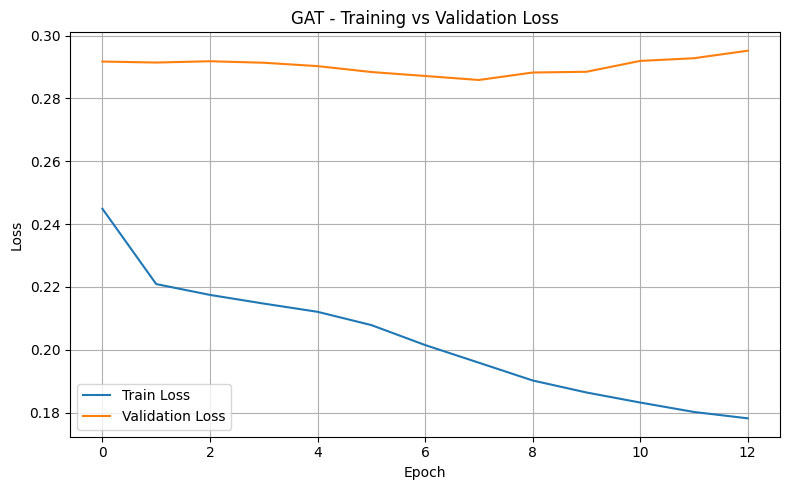

In [13]:
if MODEL_NAME != "zero":
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{MODEL_NAME.upper()} - Training vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{MODEL_NAME}_loss_curves.png", dpi=200)
    plt.show()

In [14]:
@torch.no_grad()
def collect_predictions(loader):
    model.eval()
    all_preds = []
    all_targets = []
    all_pos = []

    for batch in loader:
        batch = batch.to(DEVICE)
        pred = model(batch)

        all_preds.append(pred.cpu())
        all_targets.append(batch.target.cpu())
        all_pos.append(batch.pos.cpu())

    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    all_pos = torch.cat(all_pos, dim=0)

    return all_preds, all_targets, all_pos

preds, targets, positions = collect_predictions(test_loader)

print("preds shape:", preds.shape)
print("targets shape:", targets.shape)
print("positions shape:", positions.shape)

preds shape: torch.Size([20187, 3])
targets shape: torch.Size([20187, 3])
positions shape: torch.Size([20187, 3])


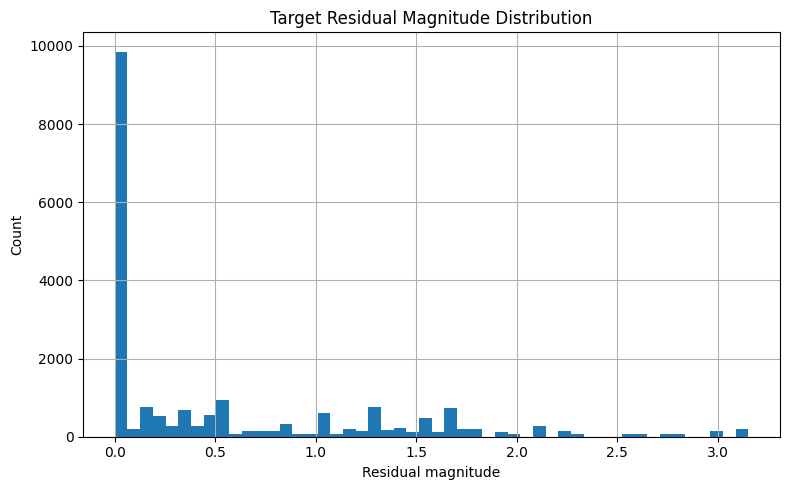

In [15]:
target_magnitudes = torch.norm(targets, dim=1)

plt.figure(figsize=(8, 5))
plt.hist(target_magnitudes.numpy(), bins=50)
plt.xlabel("Residual magnitude")
plt.ylabel("Count")
plt.title("Target Residual Magnitude Distribution")
plt.grid(True)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "residual_distribution.png", dpi=200)
plt.show()

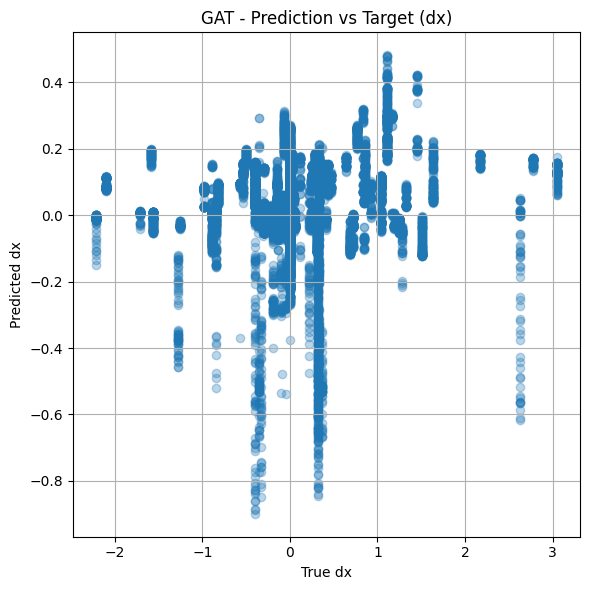

In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(targets[:, 0].numpy(), preds[:, 0].numpy(), alpha=0.3)
plt.xlabel("True dx")
plt.ylabel("Predicted dx")
plt.title(f"{MODEL_NAME.upper()} - Prediction vs Target (dx)")
plt.grid(True)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{MODEL_NAME}_prediction_vs_target_dx.png", dpi=200)
plt.show()

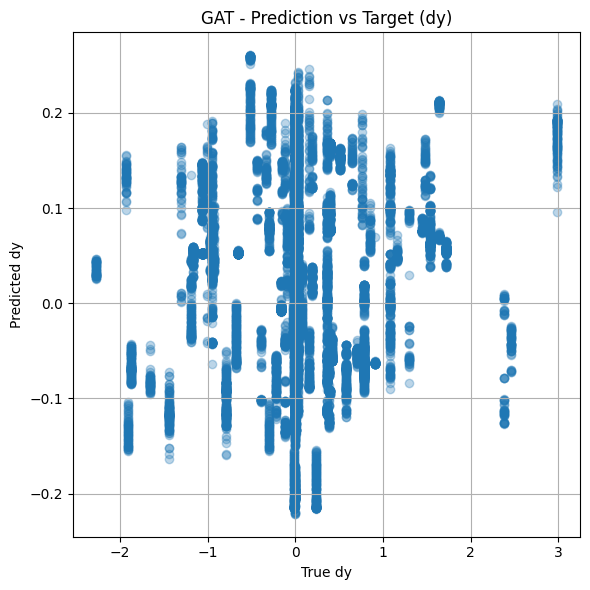

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(targets[:, 1].numpy(), preds[:, 1].numpy(), alpha=0.3)
plt.xlabel("True dy")
plt.ylabel("Predicted dy")
plt.title(f"{MODEL_NAME.upper()} - Prediction vs Target (dy)")
plt.grid(True)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{MODEL_NAME}_prediction_vs_target_dy.png", dpi=200)
plt.show()

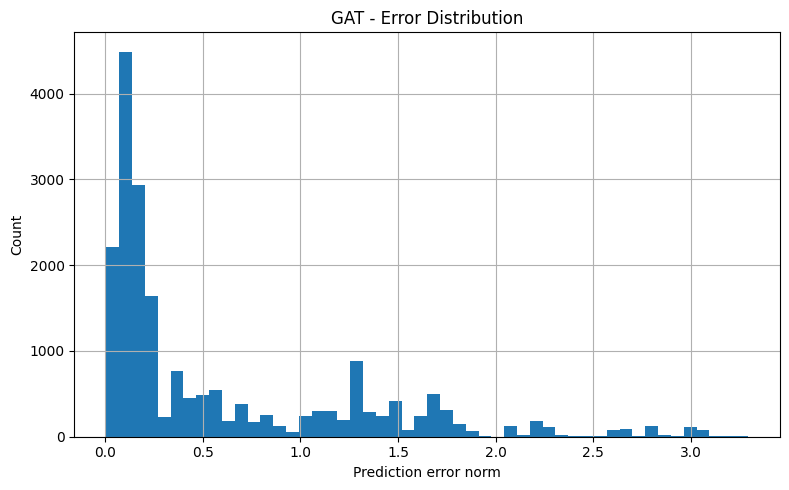

In [18]:
errors = torch.norm(preds - targets, dim=1)

plt.figure(figsize=(8, 5))
plt.hist(errors.numpy(), bins=50)
plt.xlabel("Prediction error norm")
plt.ylabel("Count")
plt.title(f"{MODEL_NAME.upper()} - Error Distribution")
plt.grid(True)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{MODEL_NAME}_error_distribution.png", dpi=200)
plt.show()

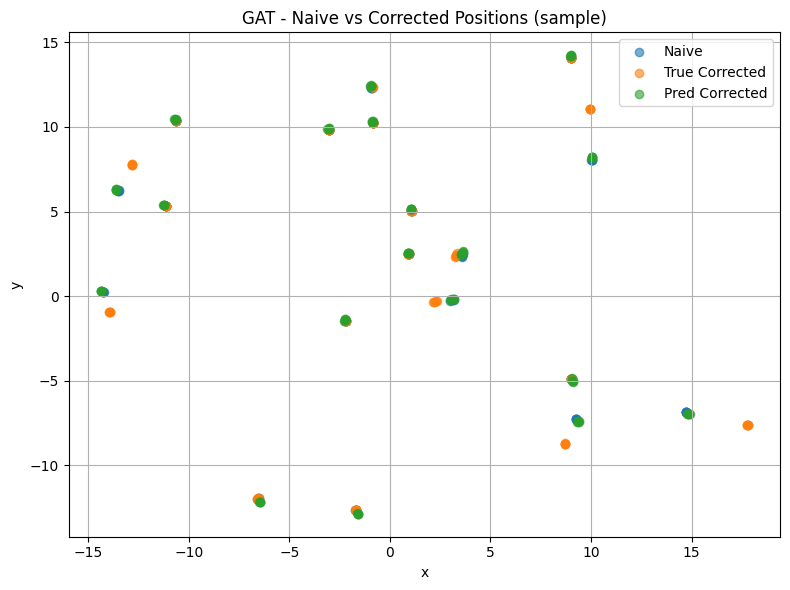

In [19]:
# Take only the first 100 nodes for readability
n_show = min(100, positions.shape[0])

naive = positions[:n_show]
true_corrected = positions[:n_show] + targets[:n_show]
pred_corrected = positions[:n_show] + preds[:n_show]

plt.figure(figsize=(8, 6))
plt.scatter(naive[:, 0].numpy(), naive[:, 1].numpy(), label="Naive", alpha=0.6)
plt.scatter(true_corrected[:, 0].numpy(), true_corrected[:, 1].numpy(), label="True Corrected", alpha=0.6)
plt.scatter(pred_corrected[:, 0].numpy(), pred_corrected[:, 1].numpy(), label="Pred Corrected", alpha=0.6)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"{MODEL_NAME.upper()} - Naive vs Corrected Positions (sample)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(RESULTS_DIR / f"{MODEL_NAME}_naive_vs_corrected_sample.png", dpi=200)
plt.show()